# Fig. 1 — Line plot: comparing two methods over epochs

This notebook demonstrates the basic plotting workflow:
1. Load the matplotlibrc file to set fonts, sizes, and style
2. Set the figure size to match the journal column width
3. Load pre-summarized data from `../data/`
4. Plot using colorblind-friendly colors from `cb_colors`
5. Save to `../pdf/`

Change `VERSION` to `"slides"` or `"dark"` to generate alternative versions.

In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from cb_colors import palettes

# ── Version switch ────────────────────────────────────────────────────────────
# Change this to generate a different version of the figure.
VERSION = "paper"   # "paper" | "slides" | "dark"

# ── Load style ────────────────────────────────────────────────────────────────
matplotlib.rc_file("../../../matplotlibrc_ml")

# ── Figure size ───────────────────────────────────────────────────────────────
# NeurIPS text width: 5.5 in (single column)
# PRL column width:   3.375 in
# → set to match your journal; the font in the figure will match the paper text
TEXTWIDTH = 5.5    # inches — NeurIPS full text width
COLWIDTH  = 2.6    # inches — half-width figure

if VERSION == "paper":
    FIGWIDTH   = COLWIDTH
    FONT_SIZE  = 7.5
    SUFFIX     = ""
    TRANSPARENT = True
elif VERSION == "slides":
    FIGWIDTH   = 4.5
    FONT_SIZE  = 13.0
    SUFFIX     = "_slides"
    TRANSPARENT = False
elif VERSION == "dark":
    FIGWIDTH   = 4.5
    FONT_SIZE  = 13.0
    SUFFIX     = "_dark"
    TRANSPARENT = True

matplotlib.rcParams.update({"font.size": FONT_SIZE})
print(f"Version: {VERSION}, figure width: {FIGWIDTH} in, font size: {FONT_SIZE} pt")

Version: paper, figure width: 2.6 in, font size: 7.5 pt


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
with open("../data/example_data.json") as f:
    data = json.load(f)

print(data["description"])

Training loss over epochs for two methods. Summarized from full training runs.


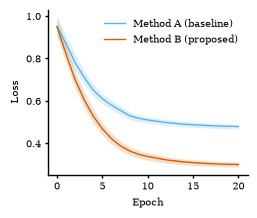

In [3]:
# ── Colors ────────────────────────────────────────────────────────────────────
# Okabe & Ito: widely recommended colorblind-safe palette
c = palettes.okabe_and_ito()

COLORS = {
    "method_a": c["lightblue"],
    "method_b": c["orange"],
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGWIDTH * 0.85))

for key, color in COLORS.items():
    d = data[key]
    x = np.array(d["x"])
    y = np.array(d["y"])
    y_std = np.array(d["y_std"])

    ax.plot(x, y, color=color, label=d["label"])
    ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.2, linewidth=0)

ax.set_xlabel(data["x_label"])
ax.set_ylabel(data["y_label"])
ax.legend()

# Dark version: invert background and adjust text/spine colors
if VERSION == "dark":
    BG = "#1c1c2e"
    FG = "white"
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.tick_params(colors=FG)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    for spine in ax.spines.values():
        spine.set_edgecolor(FG)
    ax.get_legend().get_texts()[0].set_color(FG)
    ax.get_legend().get_texts()[1].set_color(FG)

plt.tight_layout()
plt.show()

In [4]:
# ── Save ──────────────────────────────────────────────────────────────────────
out_path = f"../pdf/fig_01{SUFFIX}.pdf"
fig.savefig(out_path, transparent=TRANSPARENT)
print(f"Saved: {out_path}")

Saved: ../pdf/fig_01.pdf
